# CPU and GPU performance for cifar10 dataset

## Loading data + preprocessing

In [36]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [37]:
# Shows list of physical devices available for tensorflow
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [38]:
tf.__version__

'2.19.0'

In [39]:
tf.test.is_built_with_cuda()

True

In [40]:
# load data
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [41]:
X_train.shape

(50000, 32, 32, 3)

In [42]:
y_train.shape

(50000, 1)

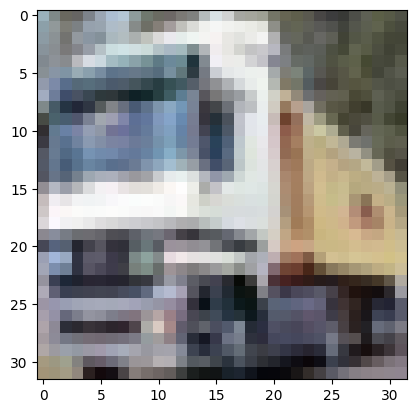

In [43]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1])

In [44]:
# Scaling images
X_train = X_train / 255
X_test = X_test / 255

In [45]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [46]:
# One hot encoding output column
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [47]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

## Defining model

In [30]:
def get_model():
  model = keras.Sequential([
      keras.layers.Flatten(input_shape=(32, 32, 3)),
      keras.layers.Dense(3000, activation='relu'),
      keras.layers.Dense(1000, activation='relu'),
      keras.layers.Dense(10, activation='sigmoid')
  ])

  model.compile(optimizer='SGD',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

## Model Training time on a CPU

In [34]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  cpu_model = get_model()
  cpu_model.fit(X_train, y_train, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.3097 - loss: 1.9267
1min 41s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [32]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  cpu_model = get_model()
  cpu_model.fit(X_train, y_train, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 63ms/step - accuracy: 0.3020 - loss: 1.9342
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 65ms/step - accuracy: 0.4195 - loss: 1.6386
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - accuracy: 0.4557 - loss: 1.5504
6min 24s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## Model Training time on a GPU

In [35]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  cpu_model = get_model()
  cpu_model.fit(X_train, y_train, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3038 - loss: 1.9300
8.31 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [33]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  cpu_model = get_model()
  cpu_model.fit(X_train, y_train, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3026 - loss: 1.9260
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4160 - loss: 1.6413
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4528 - loss: 1.5528
21.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## Performance comparison

| Epoch | CPU        | GPU     |
|-------|------------|---------|
| 1     | 1min 41 sec     |  8.31 sec   |
| 3    | 6 min 24 sec | 21.4 sec |


# CPU and GPU performance for fashion mnist dataset

## Loading data + preprocessing

In [49]:
# load data
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [50]:
X_train.shape

(60000, 28, 28)

In [51]:
y_train.shape

(60000,)

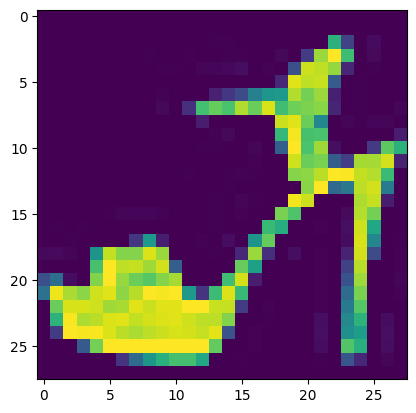

In [60]:
plt.imshow(X_train[9])

In [61]:
# Scaling images
X_train = X_train / 255
X_test = X_test / 255

In [65]:
# One hot encoding output column
y_train_encoded = keras.utils.to_categorical(y_train, 10)
y_test_encoded = keras.utils.to_categorical(y_test, 10)

## Defining model

In [79]:
def get_model(hidden_layers=1):
  layers = []
  layers.append(keras.layers.Flatten(input_shape=(28, 28)))
  for i in range(hidden_layers):
    layers.append(keras.layers.Dense(500, activation='relu'))
  layers.append(keras.layers.Dense(10, activation='sigmoid'))

  model = keras.Sequential(layers)
  model.compile(optimizer='SGD',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

## Model Training time on a CPU

In [80]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  model = get_model(1)
  model.fit(X_train, y_train_encoded, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7085 - loss: 0.9437
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8252 - loss: 0.5158
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8412 - loss: 0.4638
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8480 - loss: 0.4377
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8551 - loss: 0.4180
27.6 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [82]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  model = get_model(5)
  model.fit(X_train, y_train_encoded, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.6501 - loss: 1.0698
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8323 - loss: 0.4751
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8555 - loss: 0.4061
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8653 - loss: 0.3679
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8743 - loss: 0.3466
1min 31s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## Model Training time on a GPU

In [81]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  model = get_model(1)
  model.fit(X_train, y_train_encoded, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6986 - loss: 0.9529
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8261 - loss: 0.5203
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8417 - loss: 0.4603
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8526 - loss: 0.4310
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8558 - loss: 0.4219
22.2 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [83]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  model = get_model(5)
  model.fit(X_train, y_train_encoded, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6357 - loss: 1.1092
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8356 - loss: 0.4701
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8547 - loss: 0.4109
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8673 - loss: 0.3691
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8738 - loss: 0.3465
25.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


## Performance comparison

| Layers | CPU        | GPU     |
|-------|------------|---------|
| 1     | 27.6 sec     |  22.2 sec   |
| 5    | 1 min 31 sec | 25.4 sec |
